[load_csv] Tổng số dòng: 112120
[load_csv] Các cột: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']
Finding Labels
No Finding                           60361
Infiltration                          9547
Atelectasis                           4215
Effusion                              3955
Nodule                                2705
Pneumothorax                          2194
Mass                                  2139
Effusion|Infiltration                 1603
Atelectasis|Infiltration              1350
Consolidation                         1310
Atelectasis|Effusion                  1165
Pleural_Thickening                    1126
Cardiomegaly                          1093
Emphysema                              892
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      737
Fibrosis                               727
Ede

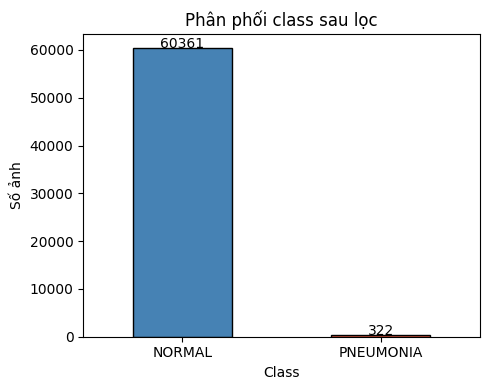

[print_statistics] Đã lưu biểu đồ → /kaggle/working/class_distribution.png
[save_filtered_csv] Đã lưu CSV sạch → /kaggle/working/filtered_dataset.csv


In [1]:
# ============================================================
# data_filtering.py  
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt



# ----------------------------------------------------------
# 1. Đường dẫn
# ----------------------------------------------------------
CSV_PATH    = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
IMAGES_ROOT = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"


# ----------------------------------------------------------
# 2. Đọc CSV
# ----------------------------------------------------------
def load_csv(csv_path: str = CSV_PATH) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    print(f"[load_csv] Tổng số dòng: {len(df)}")
    print(f"[load_csv] Các cột: {df.columns.tolist()}")
    print(df["Finding Labels"].value_counts().head(20))
    return df


# ----------------------------------------------------------
# 3. Lọc 2 class
# ----------------------------------------------------------
def filter_two_classes(df: pd.DataFrame) -> pd.DataFrame:
    mask_normal    = df["Finding Labels"] == "No Finding"
    mask_pneumonia = df["Finding Labels"] == "Pneumonia"
    df_filtered = df[mask_normal | mask_pneumonia].copy()
    df_filtered["label"] = df_filtered["Finding Labels"].map(
        {"No Finding": "NORMAL", "Pneumonia": "PNEUMONIA"}
    )
    df_filtered = df_filtered[["Image Index", "label"]].reset_index(drop=True)
    print(f"\n[filter_two_classes] Sau lọc: {len(df_filtered)} ảnh")
    print(df_filtered["label"].value_counts())
    return df_filtered


# ----------------------------------------------------------
# 4. [SỬA] Gắn đường dẫn ảnh — duyệt đệ quy toàn bộ IMAGES_ROOT
# ----------------------------------------------------------
def attach_image_paths(df: pd.DataFrame, images_root: str = IMAGES_ROOT) -> pd.DataFrame:
    """
    SỬA LỖI: Dùng os.walk() thay vì os.listdir() 1 cấp.
    os.walk() duyệt đệ quy tất cả subfolder nên tìm được ảnh
    dù cấu trúc là images_001/images/*.png hay bất kỳ cấp nào.
    Đồng thời in ra 5 path mẫu để dễ debug.
    """
    print(f"[attach_image_paths] Đang quét đệ quy: {images_root}")
    path_map = {}
    for root, dirs, files in os.walk(images_root):
        for fname in files:
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                # Nếu trùng tên file, ưu tiên path tìm thấy đầu tiên
                if fname not in path_map:
                    path_map[fname] = os.path.join(root, fname)

    print(f"[attach_image_paths] Tổng file ảnh tìm thấy: {len(path_map)}")

    # Debug: in 5 path mẫu để kiểm tra cấu trúc thực tế
    sample_keys = list(path_map.keys())[:5]
    print("[attach_image_paths] Mẫu path tìm được:")
    for k in sample_keys:
        print(f"  {path_map[k]}")

    df = df.copy()
    df["image_path"] = df["Image Index"].map(path_map)

    missing = df["image_path"].isna().sum()
    if missing > 0:
        print(f"[attach_image_paths] Cảnh báo: {missing} ảnh không tìm thấy → bỏ qua")
        df = df.dropna(subset=["image_path"]).reset_index(drop=True)

    print(f"[attach_image_paths] Còn lại {len(df)} ảnh có đường dẫn hợp lệ")
    return df


# ----------------------------------------------------------
# 5. [SỬA] Thống kê — guard khi DataFrame rỗng
# ----------------------------------------------------------
def print_statistics(df: pd.DataFrame):
    print("\n===== THỐNG KÊ DATASET =====")

    # SỬA LỖI: Kiểm tra rỗng trước khi vẽ
    if df.empty:
        print("[print_statistics] DataFrame rỗng, không có gì để thống kê.")
        print("  → Kiểm tra lại IMAGES_ROOT và cấu trúc thư mục ảnh.")
        return

    counts = df["label"].value_counts()
    print(counts.to_string())
    total = len(df)
    for cls, cnt in counts.items():
        print(f"  {cls}: {cnt} ảnh ({cnt/total*100:.1f}%)")

    fig, ax = plt.subplots(figsize=(5, 4))
    counts.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="black")
    ax.set_title("Phân phối class sau lọc")
    ax.set_xlabel("Class")
    ax.set_ylabel("Số ảnh")
    ax.set_xticklabels(counts.index, rotation=0)
    for i, v in enumerate(counts):
        ax.text(i, v + 30, str(v), ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig("/kaggle/working/class_distribution.png", dpi=120)
    plt.show()
    print("[print_statistics] Đã lưu biểu đồ → /kaggle/working/class_distribution.png")


def save_filtered_csv(df: pd.DataFrame, out_path: str = "/kaggle/working/filtered_dataset.csv"):
    if df.empty:
        print("[save_filtered_csv] DataFrame rỗng, không lưu.")
        return
    df.to_csv(out_path, index=False)
    print(f"[save_filtered_csv] Đã lưu CSV sạch → {out_path}")


# ----------------------------------------------------------
# 6. Hàm tổng hợp
# ----------------------------------------------------------
def run_filtering() -> pd.DataFrame:
    df_raw      = load_csv()
    df_filtered = filter_two_classes(df_raw)
    df_filtered = attach_image_paths(df_filtered)
    print_statistics(df_filtered)
    save_filtered_csv(df_filtered)
    return df_filtered


if __name__ == "__main__":
    df_clean = run_filtering()

In [2]:
# ============================================================
# data_preprocessing.py
# Mục đích: Định nghĩa transforms cho train / val / test.
#           Có hàm minh họa ảnh trước và sau preprocessing.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms


# ----------------------------------------------------------
# 1. Hằng số chuẩn ImageNet (ResNet18 pretrained dùng các giá trị này)
# ----------------------------------------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMAGE_SIZE    = 224


# ----------------------------------------------------------
# 2. Transform cho tập TRAIN (có augmentation)
# ----------------------------------------------------------
train_transform = transforms.Compose([
    # Resize về 256 trước để có biên khi crop
    transforms.Resize(256),
    # Random crop ra đúng 224×224 — tăng tính đa dạng vị trí
    transforms.RandomCrop(IMAGE_SIZE),
    # Lật ngang ngẫu nhiên (50%) — X-quang đối xứng nên ok
    transforms.RandomHorizontalFlip(p=0.5),
    # Xoay nhẹ (±10°) — mô phỏng ảnh chụp hơi nghiêng
    transforms.RandomRotation(degrees=10),
    # Thay đổi độ sáng/tương phản nhẹ — mô phỏng máy X-quang khác nhau
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # Chuyển sang Tensor (HWC → CHW, giá trị 0–1)
    transforms.ToTensor(),
    # Normalize theo chuẩn ImageNet
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


# ----------------------------------------------------------
# 3. Transform cho tập VAL và TEST (KHÔNG augment — đánh giá khách quan)
# ----------------------------------------------------------
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    # Center crop: lấy chính giữa — không random
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


# ----------------------------------------------------------
# 4. Hàm tiện ích: đảo Normalize để vẽ ảnh ra màn hình
# ----------------------------------------------------------
def denormalize(tensor):
    """
    Đảo ngược Normalize để có thể hiển thị ảnh.
    tensor: shape (C, H, W), giá trị đã normalize
    Trả về numpy array (H, W, C) giá trị 0–1
    """
    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    img  = tensor.permute(1, 2, 0).numpy()   # (C,H,W) → (H,W,C)
    img  = img * std + mean                   # đảo normalize
    img  = np.clip(img, 0, 1)
    return img


# ----------------------------------------------------------
# 5. Minh họa ảnh trước/sau preprocessing
# ----------------------------------------------------------
def visualize_preprocessing(image_paths: list, n: int = 4):
    """
    Vẽ n ảnh: cột trái = ảnh gốc, cột phải = sau train_transform.
    image_paths: list đường dẫn ảnh
    """
    n = min(n, len(image_paths))
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 3))
    if n == 1:
        axes = [axes]

    fig.suptitle("Ảnh gốc  vs  Sau preprocessing (train_transform)", fontsize=13)

    for i, path in enumerate(image_paths[:n]):
        # --- ảnh gốc ---
        img_pil = Image.open(path).convert("RGB")
        axes[i][0].imshow(img_pil, cmap="gray" if img_pil.mode == "L" else None)
        axes[i][0].set_title(f"Gốc  {img_pil.size[0]}×{img_pil.size[1]}", fontsize=9)
        axes[i][0].axis("off")

        # --- sau transform ---
        tensor = train_transform(img_pil)
        img_np = denormalize(tensor)
        axes[i][1].imshow(img_np)
        axes[i][1].set_title(f"Sau xử lý  {IMAGE_SIZE}×{IMAGE_SIZE}", fontsize=9)
        axes[i][1].axis("off")

    plt.tight_layout()
    plt.savefig("/kaggle/working/preprocessing_demo.png", dpi=120)
    plt.show()
    print("[visualize_preprocessing] Đã lưu → /kaggle/working/preprocessing_demo.png")


# Chạy trực tiếp để kiểm tra (cần truyền vào vài đường dẫn ảnh)
if __name__ == "__main__":
    print("train_transform:")
    print(train_transform)
    print("\nval_test_transform:")
    print(val_test_transform)

train_transform:
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

val_test_transform:
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [3]:
%%writefile data_preprocessing.py
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMAGE_SIZE    = 224

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),          # ← thêm
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # ← thêm
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),              # ← nên dùng CenterCrop
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def denormalize(tensor):
    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    img  = tensor.permute(1, 2, 0).numpy()
    img  = img * std + mean
    return np.clip(img, 0, 1)

def visualize_preprocessing(image_paths: list, n: int = 4):
    n = min(n, len(image_paths))
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 3))
    if n == 1:
        axes = [axes]
    fig.suptitle("Ảnh gốc  vs  Sau preprocessing", fontsize=13)
    for i, path in enumerate(image_paths[:n]):
        img_pil = Image.open(path).convert("RGB")
        axes[i][0].imshow(img_pil)
        axes[i][0].set_title(f"Gốc {img_pil.size[0]}×{img_pil.size[1]}", fontsize=9)
        axes[i][0].axis("off")
        tensor = train_transform(img_pil)
        axes[i][1].imshow(denormalize(tensor))
        axes[i][1].set_title(f"Sau xử lý {IMAGE_SIZE}×{IMAGE_SIZE}", fontsize=9)
        axes[i][1].axis("off")
    plt.tight_layout()
    plt.savefig("/kaggle/working/preprocessing_demo.png", dpi=120)
    plt.show()

Writing data_preprocessing.py



===== PHÂN CHIA DATASET =====
  Train: 42477 ảnh  |  NORMAL=42251  PNEUMONIA=226
  Val  :  9103 ảnh  |  NORMAL=9055  PNEUMONIA=48
  Test :  9103 ảnh  |  NORMAL=9055  PNEUMONIA=48

===== DATALOADER =====
  batch_size  : 32
  train_loader: 1328 batch (42477 ảnh)
  val_loader  : 285 batch (9103 ảnh)
  test_loader : 285 batch (9103 ảnh)


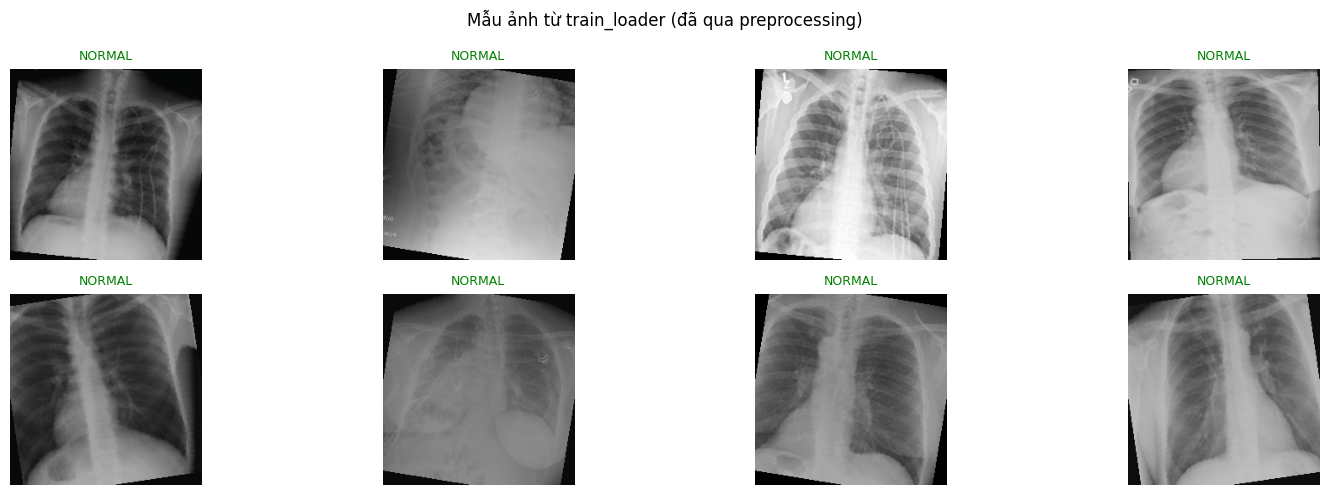

[visualize_batch] Đã lưu → /kaggle/working/batch_sample.png


In [4]:
# ============================================================
# dataset.py
# Mục đích: Định nghĩa ChestXrayDataset + chia train/val/test
#           + tạo DataLoader sẵn sàng cho Task 2.
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import sys
sys.path.append('/kaggle/working')  

import torch
from torch.utils.data import Dataset, DataLoader

# Import từ 2 file đã tạo ở trên

from data_preprocessing import train_transform, val_test_transform

# ----------------------------------------------------------
# 1. Mapping nhãn chữ → số
# ----------------------------------------------------------
LABEL_MAP = {
    "NORMAL":    0,
    "PNEUMONIA": 1,
}


# ----------------------------------------------------------
# 2. Class Dataset
# ----------------------------------------------------------
class ChestXrayDataset(Dataset):
    """
    Dataset ảnh X-quang ngực cho bài toán phân loại nhị phân.

    Tham số:
        df        : DataFrame với cột 'image_path' và 'label' (chữ)
        transform : torchvision transform áp dụng lên ảnh
    """

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = row["image_path"]
        label = LABEL_MAP[row["label"]]   # NORMAL→0, PNEUMONIA→1

        # Mở ảnh và chuyển sang RGB (X-quang gốc thường là grayscale,
        # nhưng ResNet cần 3 channel)
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# ----------------------------------------------------------
# 3. Chia train / val / test
# ----------------------------------------------------------
def split_dataset(df: pd.DataFrame,
                  train_ratio: float = 0.70,
                  val_ratio:   float = 0.15,
                  test_ratio:  float = 0.15,
                  random_state: int  = 42) -> tuple:
    """
    Chia DataFrame thành 3 tập với tỉ lệ mặc định 70/15/15.
    stratify=label đảm bảo mỗi tập có cùng tỉ lệ NORMAL/PNEUMONIA.

    Trả về: (df_train, df_val, df_test)
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, \
        "Tổng 3 tỉ lệ phải bằng 1.0"

    # Tách test trước
    df_train_val, df_test = train_test_split(
        df,
        test_size=test_ratio,
        stratify=df["label"],
        random_state=random_state,
    )

    # Tách val từ phần còn lại
    val_size_adjusted = val_ratio / (train_ratio + val_ratio)
    df_train, df_val = train_test_split(
        df_train_val,
        test_size=val_size_adjusted,
        stratify=df_train_val["label"],
        random_state=random_state,
    )

    print("\n===== PHÂN CHIA DATASET =====")
    for name, subset in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
        counts = subset["label"].value_counts()
        print(f"  {name:5s}: {len(subset):5d} ảnh  |  "
              f"NORMAL={counts.get('NORMAL',0)}  PNEUMONIA={counts.get('PNEUMONIA',0)}")

    return df_train, df_val, df_test


# ----------------------------------------------------------
# 4. Tạo DataLoader
# ----------------------------------------------------------
def create_dataloaders(df_train, df_val, df_test,
                       batch_size=32, num_workers=2):
    
    # Tự động detect có GPU không
    use_pin_memory = torch.cuda.is_available()

    train_dataset = ChestXrayDataset(df_train, transform=train_transform)
    val_dataset   = ChestXrayDataset(df_val,   transform=val_test_transform)
    test_dataset  = ChestXrayDataset(df_test,  transform=val_test_transform)

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size,
        shuffle=True, num_workers=num_workers,
        pin_memory=use_pin_memory,   # ← thay True bằng này
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size,
        shuffle=False, num_workers=num_workers,
        pin_memory=use_pin_memory,
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size,
        shuffle=False, num_workers=num_workers,
        pin_memory=use_pin_memory,
    )
    print(f"\n===== DATALOADER =====")
    print(f"  batch_size  : {batch_size}")
    print(f"  train_loader: {len(train_loader)} batch ({len(train_dataset)} ảnh)")
    print(f"  val_loader  : {len(val_loader)} batch ({len(val_dataset)} ảnh)")
    print(f"  test_loader : {len(test_loader)} batch ({len(test_dataset)} ảnh)")

    return train_loader, val_loader, test_loader


# ----------------------------------------------------------
# 5. Minh họa một batch mẫu
# ----------------------------------------------------------
def visualize_batch(loader: DataLoader, n: int = 8):
    """Lấy 1 batch từ loader và hiển thị n ảnh đầu."""
    from data_preprocessing import denormalize

    images, labels = next(iter(loader))
    label_names = {v: k for k, v in LABEL_MAP.items()}

    n   = min(n, len(images))
    fig, axes = plt.subplots(2, n // 2, figsize=(n * 2, 5))
    axes = axes.flatten()

    for i in range(n):
        img_np = denormalize(images[i])
        axes[i].imshow(img_np)
        cls = label_names[labels[i].item()]
        color = "red" if cls == "PNEUMONIA" else "green"
        axes[i].set_title(cls, color=color, fontsize=9)
        axes[i].axis("off")

    plt.suptitle("Mẫu ảnh từ train_loader (đã qua preprocessing)", fontsize=12)
    plt.tight_layout()
    plt.savefig("/kaggle/working/batch_sample.png", dpi=120)
    plt.show()
    print("[visualize_batch] Đã lưu → /kaggle/working/batch_sample.png")


# ----------------------------------------------------------
# 6. Hàm tổng hợp — gọi một lần từ notebook
# ----------------------------------------------------------
def build_dataloaders(df_clean: pd.DataFrame,
                      batch_size: int = 32) -> tuple:
    """
    Nhận df_clean (output của data_filtering.py),
    trả về (train_loader, val_loader, test_loader, df_train, df_val, df_test).
    """
    df_train, df_val, df_test = split_dataset(df_clean)
    train_loader, val_loader, test_loader = create_dataloaders(
        df_train, df_val, df_test, batch_size=batch_size
    )
    return train_loader, val_loader, test_loader, df_train, df_val, df_test


# Chạy trực tiếp để test
if __name__ == "__main__":
    # Giả sử đã có file CSV sạch từ data_filtering.py
    df = pd.read_csv("/kaggle/working/filtered_dataset.csv")
    train_loader, val_loader, test_loader, *_ = build_dataloaders(df)
    visualize_batch(train_loader)